# **Importing and Loading Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from glob import glob
import librosa
import librosa.display
import IPython.display as ipd
from itertools import cycle
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing

# **Explore Audio Data**

We will use librosa, which is the mother of audio files.

# **Understanding Audio**

Let's first Explore our Audio Data to see how it looks (we'll work with Congolese Rumba 002 wav file).

Sound: sequence of vibrations in varying pressure strengths (y)
The sample rate (sr) is the number of samples of audio carried per second, measured in Hz or kHz

# **Audio Feature Extraction**

In [ ]:
from glob import glob
import IPython.display as ipd

audio_files = glob('/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/Congolese Rumba/Trimmed/Congolese Rumba 002.wav')

print(len(audio_files))
ipd.Audio(audio_files[0])



In [ ]:
pip install pydub

In [ ]:
Y, sample_rate = librosa.load(audio_files[0])
print(f"Output Y or the raw data of audio file: ", Y)
print(Y.shape)
print("Data type: ", type(Y))
print("Sample rate: ", sample_rate)
print("Data type: ", type(sample_rate))

Output Y or the raw data of audio file:  [-0.1934783  -0.27995777 -0.26756614 ...  0.04544196  0.05497012
  0.        ]
(652603,)
Data type:  <class 'numpy.ndarray'>
Sample rate:  22050
Data type:  <class 'int'>


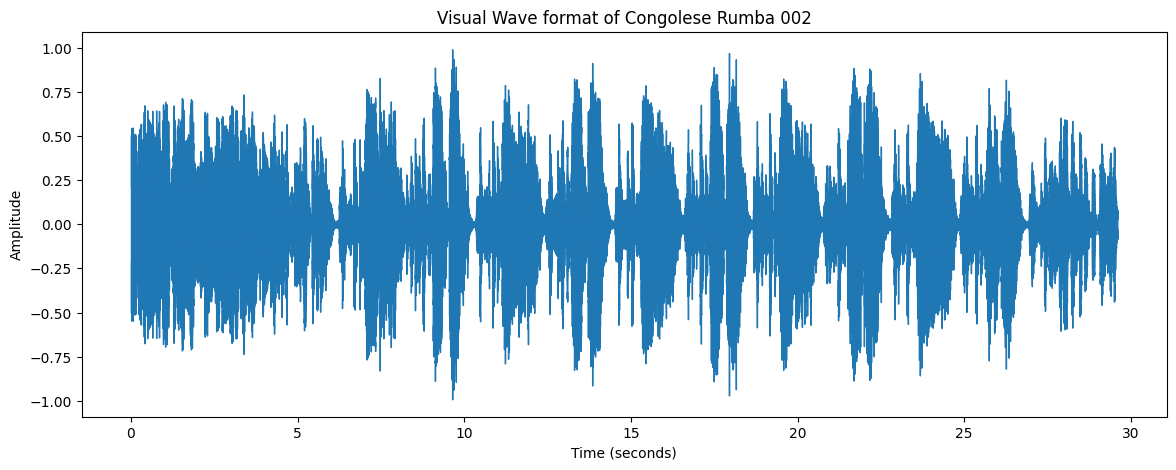

In [ ]:
# To View Wave form of Congolese Rumba 002

plt.figure(figsize=(14, 5))
# Use the Y and sample_rate you already loaded
librosa.display.waveshow(Y, sr=sample_rate)
plt.title('Visual Wave format of Congolese Rumba 002')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

<class 'pandas.core.series.Series'>


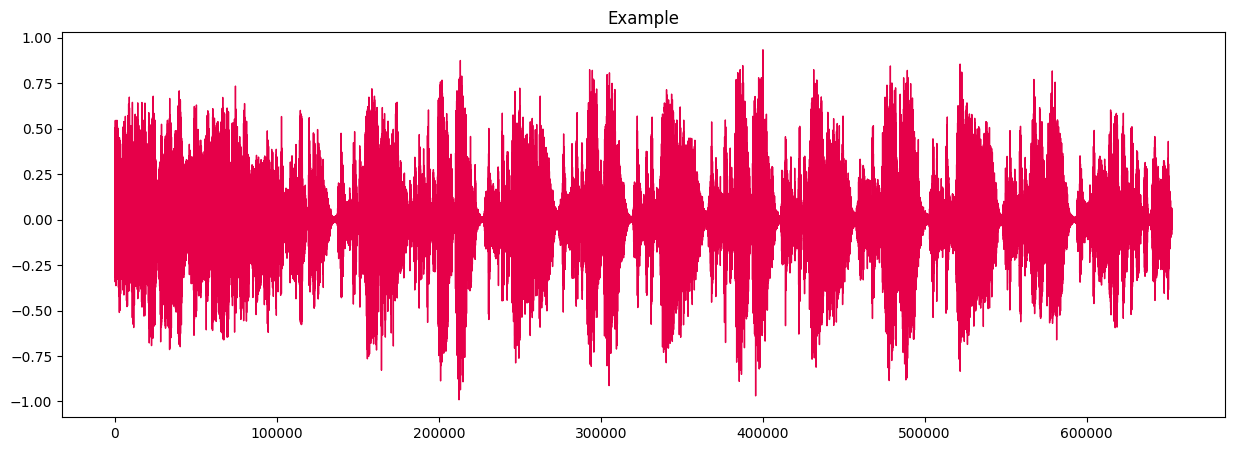

In [ ]:
audio_example_1=pd.Series(Y) #converting into panda series
print(type(audio_example_1))
audio_example_1.plot(figsize=(15,5), lw=1, title="Example", color='#e60049')
plt.show()

<class 'pandas.core.series.Series'>


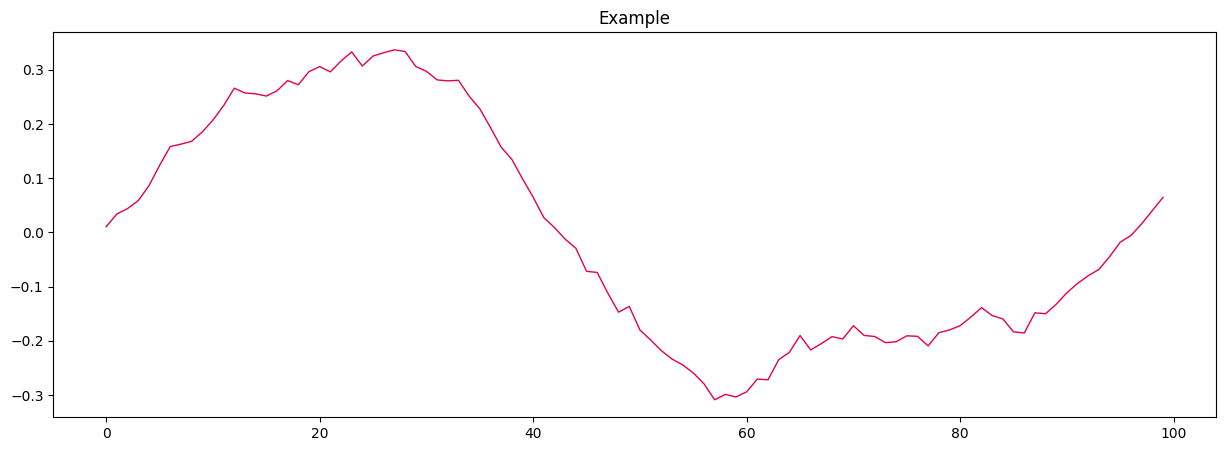

In [ ]:
#zoomed in version of the same plot
audio_example_2=pd.Series(Y[450000:450100]) #converting into panda series
print(type(audio_example_2))
audio_example_2.plot(figsize=(15,5), lw=1, title="Example", color='#e60049')
plt.show()

In [ ]:
# 1. Load the file (Ensure it loads at 22050 Hz for consistency)
y, sr = librosa.load(audio_files[0], sr=22050)

# 2. Print Data details
print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample Rate (Hz):', sr, '\n')

# 3. Verify Length of the Audio
# For your dataset, you want this to result in exactly 30.0
print(f'Check Len of Audio: {len(y)} samples / {sr} Hz = {len(y)/sr:.2f} seconds')


y: [-0.1934783  -0.27995777 -0.26756614 ...  0.04544196  0.05497012
  0.        ] 

y shape: (652603,) 

Sample Rate (Hz): 22050 

Check Len of Audio: 652603 samples / 22050 Hz = 29.60 seconds


# **Filling up the features to 30 seconds**

As we have observed Congolese Rumba 002 wav file stops at 29.60 seconds and 30:00 seconds is required, lets fill it up

In [ ]:
# 1. Define the target length in samples
# 30 seconds * 22050 Hz = 661,500 samples
target_length = 30 * sr

# 2. Calculate how much is missing
current_length = len(y)
missing_samples = target_length - current_length

# 3. Pad the array with zeros if it's too short
if missing_samples > 0:
    # np.pad(array, (pad_beginning, pad_end), mode)
    y_fixed = np.pad(y, (0, missing_samples), mode='constant')
    print(f"Padded {missing_samples} samples of silence.")
else:
    y_fixed = y
    print("File was already 30s or longer.")

# 4. Verify the new length
print('\n--- verification ---')
print('Old Duration:', current_length / sr, 'seconds')
print('New Duration:', len(y_fixed) / sr, 'seconds')
print('New Shape:', y_fixed.shape)

# 5. Update your main variable 'y' to use this fixed version
y = y_fixed

Padded 8897 samples of silence.

--- verification ---
Old Duration: 29.596507936507937 seconds
New Duration: 30.0 seconds
New Shape: (661500,)


# **Short Time Fourier Transform**

**Fourier Transform**

This is a Function that gets a signal in the time domain as input, and outputs its decomposition into frequencies
Transform both the y-axis (frequency) to log scale, and the “color” axis (amplitude) to Decibels, which is approx. the log scale of amplitudes.

In [ ]:
audio_stft = librosa.stft(Y)
print("Short Time Fourier Transform:\n", audio_stft)
audio_db = librosa.amplitude_to_db(np.abs(audio_stft), ref=np.max) #amplitude to decibel conversion
print("To decibel:\n", audio_db)
print(audio_db.shape)

Short Time Fourier Transform:
 [[ 2.8666730e+00+0.0000000e+00j  1.0329741e+00+0.0000000e+00j
   1.9076455e-01+0.0000000e+00j ...  3.2808363e-01+0.0000000e+00j
   7.6144136e-02+0.0000000e+00j -2.2196367e-01+0.0000000e+00j]
 [-3.3142290e+00-2.5147760e-01j  8.6653936e-01-1.5658492e+00j
  -4.5673180e-01+7.1204478e-01j ... -8.6789101e-02-1.7492297e-01j
  -1.0757014e-01-9.4388351e-02j  1.8911591e-01-1.8053669e-01j]
 [ 3.7871506e+00-3.0235541e-01j -2.7658420e+00+3.4734726e-01j
   8.8080221e-01-2.4767268e-01j ... -3.5978922e-01-2.1781962e-02j
   9.2685737e-02+1.2996536e-01j  8.2715750e-03+1.8120480e-01j]
 ...
 [ 1.9810135e-02+1.2799641e-03j -1.0223421e-02-6.1944465e-04j
  -4.5184997e-06-1.2863447e-06j ...  7.6391316e-08+4.5127200e-07j
  -1.2923129e-03+3.5148184e-03j  1.1269381e-02-3.0702656e-02j]
 [-1.9779906e-02-6.3930504e-04j -3.0955393e-04+1.0207410e-02j
  -4.2219540e-06+2.9021143e-07j ...  3.0629948e-07+2.1587206e-07j
  -3.0702448e-03+2.1423567e-03j  1.8719794e-02+2.6811171e-02j]
 [ 1.9770

# **Accessing Spectrogram**

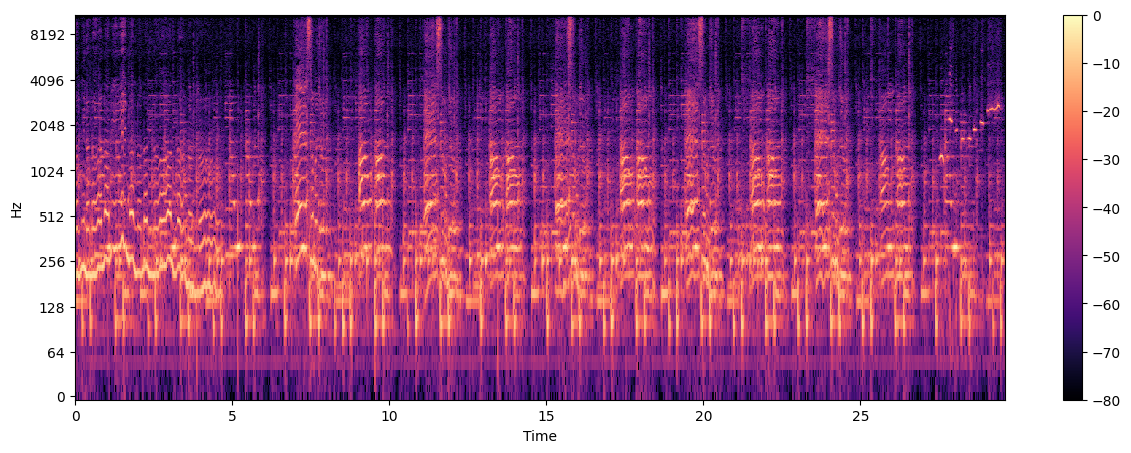

In [ ]:
fig, axis = plt.subplots(figsize=(15,5))
img = librosa.display.specshow(audio_db,
                              x_axis='time',
                              y_axis='log',
                              ax=axis) #shows how diff freq change their intensities over time
fig.colorbar(img, ax=axis)
plt.show()

In [ ]:
melspec = librosa.feature.melspectrogram(y=Y, sr=sample_rate, n_mels=128)
print(melspec.shape)
print(melspec)

(128, 1275)
[[1.21242332e+00 4.66642320e-01 1.04998551e-01 ... 2.41715219e-02
  2.61967629e-02 3.74629684e-02]
 [1.17063498e+00 3.28308940e-01 1.80581808e-01 ... 7.22859353e-02
  1.59993097e-01 1.31930545e-01]
 [1.92148042e+00 7.27016628e-01 7.04892576e-02 ... 3.15982270e+00
  9.44321036e-01 4.29800093e-01]
 ...
 [1.14037527e-03 2.46563531e-03 2.16713827e-03 ... 1.55168847e-04
  1.61265372e-04 1.70162457e-04]
 [5.64585789e-04 8.72947625e-04 6.88704487e-04 ... 9.09653172e-05
  1.01411330e-04 2.02389332e-04]
 [1.45533035e-04 5.75859995e-05 1.97567879e-05 ... 1.26294372e-05
  1.14628847e-05 1.21229015e-04]]


# **MEL Spectrogram**

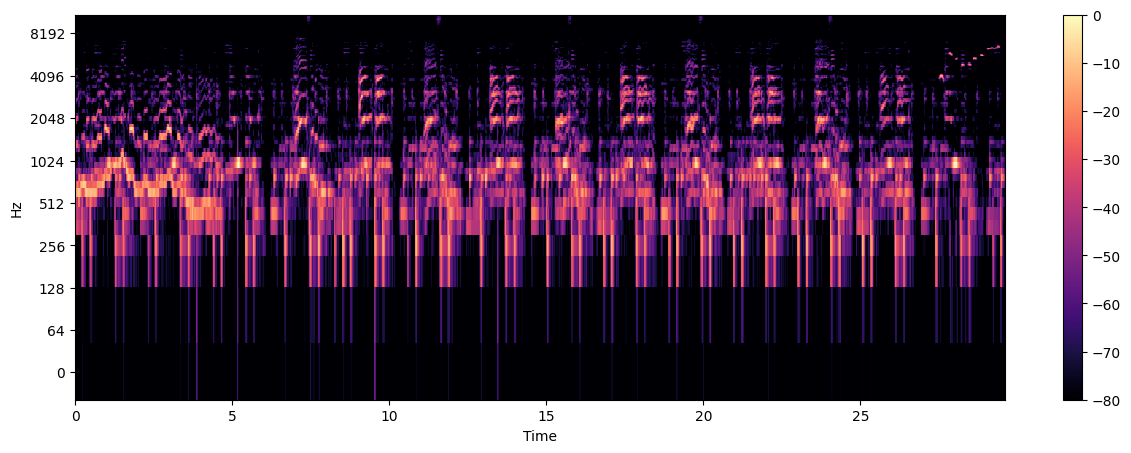

In [ ]:
melspec_db = librosa.amplitude_to_db(np.abs(melspec), ref=np.max)
fig, axis = plt.subplots(figsize=(15,5))
img = librosa.display.specshow(melspec_db,
                              x_axis='time',
                              y_axis='log',
                              ax=axis) #shows how diff freq change their intensities over time
fig.colorbar(img, ax=axis)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Application Of Machine Learning Algorithms**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/African Music Genre classifier Dataset/AMGC Dataset/1. Extracted_Features/amgc_features_upgraded.csv")

In [ ]:
df.head()

,file_name,file_path,genre,zcr_mean,zcr_var,rms_mean,rms_var,tempo,spectral_centroid_mean,spectral_centroid_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,Afrobeat 003.wav,/content/drive/MyDrive/African Music Genre cla...,Afrobeat,0.145020,0.006966,0.193634,0.004062,117.453835,3391.701187,6.795211e+05,...,-0.477758,70.578773,-8.806712,66.180794,0.135075,59.939819,-3.892154,48.529602,1.476683,56.685616
1,Afrobeat 005.wav,/content/drive/MyDrive/African Music Genre cla...,Afrobeat,0.122327,0.011564,0.177373,0.004692,161.499023,2746.984208,1.280093e+06,...,-0.109235,43.667202,-6.959187,56.299583,-3.768285,50.402672,-4.666596,48.857849,2.206328,56.457336
2,Afrobeat 004.wav,/content/drive/MyDrive/African Music Genre cla...,Afrobeat,0.134288,0.007509,0.095835,0.001943,135.999178,2375.243353,8.921724e+05,...,1.720271,42.642639,-9.229674,35.883675,-2.066906,47.223690,-7.677931,49.486034,1.612157,45.116489
3,Afrobeat 002.wav,/content/drive/MyDrive/African Music Genre cla...,Afrobeat,0.075097,0.001868,0.176112,0.006561,172.265625,1617.000931,4.514311e+05,...,-3.633174,87.402267,3.283936,94.794876,1.048155,69.117844,-1.103643,63.119213,-2.406410,71.353241
4,Afrobeat 001.wav,/content/drive/MyDrive/African Music Genre cla...,Afrobeat,0.082324,0.001229,0.255733,0.005001,95.703125,2137.921985,6.430449e+05,...,-0.958658,48.943821,-6.757425,55.476868,-2.227645,46.573841,-2.293265,59.373894,-0.588619,39.660519


In [ ]:
df.tail()

,file_name,file_path,genre,zcr_mean,zcr_var,rms_mean,rms_var,tempo,spectral_centroid_mean,spectral_centroid_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
1056,Soukous 095.wav,/content/drive/MyDrive/African Music Genre cla...,Soukous,0.099111,0.001530,0.191998,0.002623,161.499023,2619.619638,3.901990e+05,...,-3.406986,45.222664,-7.574344,53.495270,0.311113,40.559635,-3.972438,39.405075,-3.319262,35.640224
1057,Soukous 096.wav,/content/drive/MyDrive/African Music Genre cla...,Soukous,0.137486,0.003374,0.176354,0.003952,129.199219,2873.291253,3.926992e+05,...,1.744702,58.652382,-7.084126,58.788063,2.248591,69.456406,-3.738185,71.357018,-3.344683,61.296288
1058,Soukous 086.wav,/content/drive/MyDrive/African Music Genre cla...,Soukous,0.129968,0.007936,0.097461,0.005740,123.046875,3011.117164,1.091928e+06,...,-0.847109,85.031326,-7.456455,69.629234,-1.132261,94.175468,-6.308165,129.167038,-0.171136,105.363358
1059,Soukous 099.wav,/content/drive/MyDrive/African Music Genre cla...,Soukous,0.109815,0.002801,0.190050,0.003296,129.199219,2687.764294,4.017477e+05,...,-1.327418,72.523186,-7.749607,60.971992,0.167422,53.486088,-4.974340,62.970982,-0.988369,71.617737
1060,Soukous 108.wav,/content/drive/MyDrive/African Music Genre cla...,Soukous,0.094474,0.001103,0.185628,0.003107,117.453835,2521.549326,3.817639e+05,...,-0.244555,72.825455,-3.838071,58.202049,1.771411,64.929588,-5.350967,61.680367,1.062712,95.437920


In [ ]:
from sklearn.model_selection import train_test_split

#shuffle the dataset
df = df.sample(frac=1).reset_index(drop=True)

#train_test_split
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train (training featuers): ", X_train.shape)
print("Shape of X_test (testing featuers): ", X_test.shape)
print("Shape of y_train (training labels): ", y_train.shape)
print("Shape of y_test (testing labels): ", y_train.shape)

Shape of X_train (training featuers):  (848, 93)
Shape of X_test (testing featuers):  (213, 93)
Shape of y_train (training labels):  (848,)
Shape of y_test (testing labels):  (848,)


In [ ]:
import pandas as pd

X_train_num = X_train.select_dtypes(include="number")
X_test_num  = X_test.select_dtypes(include="number")

Mean_train  = X_train_num.mean()
Mean_test   = X_test_num.mean()
stdev_train = X_train_num.std()
stdev_test  = X_test_num.std()

print("Mean:\n", Mean_train, "\n\nStandard Deviation:\n", stdev_train)


Mean:
 zcr_mean         0.097348
zcr_var          0.003401
rms_mean         0.206547
rms_var          0.005243
tempo          120.638045
                  ...    
mfcc18_mean      0.402557
mfcc18_var      55.967163
mfcc19_mean     -3.274294
mfcc19_var      58.933838
mfcc20_mean      0.105226
Length: 90, dtype: float64 

Standard Deviation:
 zcr_mean        0.032887
zcr_var         0.003080
rms_mean        0.078378
rms_var         0.004221
tempo          22.209132
                 ...    
mfcc18_mean     3.391862
mfcc18_var     18.704300
mfcc19_mean     3.336736
mfcc19_var     24.070453
mfcc20_mean     3.452564
Length: 90, dtype: float64


In [ ]:
print(X_train.dtypes.value_counts())
print(X_train.columns[X_train.dtypes == "object"][:20])


float64    90
object      3
Name: count, dtype: int64
Index(['file_name', 'file_path', 'genre'], dtype='object')


In [ ]:
X_train_num = X_train.select_dtypes(include="number")
X_test_num  = X_test.select_dtypes(include="number")

Mean_train  = X_train_num.mean()
stdev_train = X_train_num.std()

print("Mean:\n{}\n\nStandard Deviation:\n{}".format(Mean_train, stdev_train))


Mean:
zcr_mean         0.097348
zcr_var          0.003401
rms_mean         0.206547
rms_var          0.005243
tempo          120.638045
                  ...    
mfcc18_mean      0.402557
mfcc18_var      55.967163
mfcc19_mean     -3.274294
mfcc19_var      58.933838
mfcc20_mean      0.105226
Length: 90, dtype: float64

Standard Deviation:
zcr_mean        0.032887
zcr_var         0.003080
rms_mean        0.078378
rms_var         0.004221
tempo          22.209132
                 ...    
mfcc18_mean     3.391862
mfcc18_var     18.704300
mfcc19_mean     3.336736
mfcc19_var     24.070453
mfcc20_mean     3.452564
Length: 90, dtype: float64


/tmp/ipykernel_585/3548766504.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='mfcc1_mean', data=df, palette='Set2')


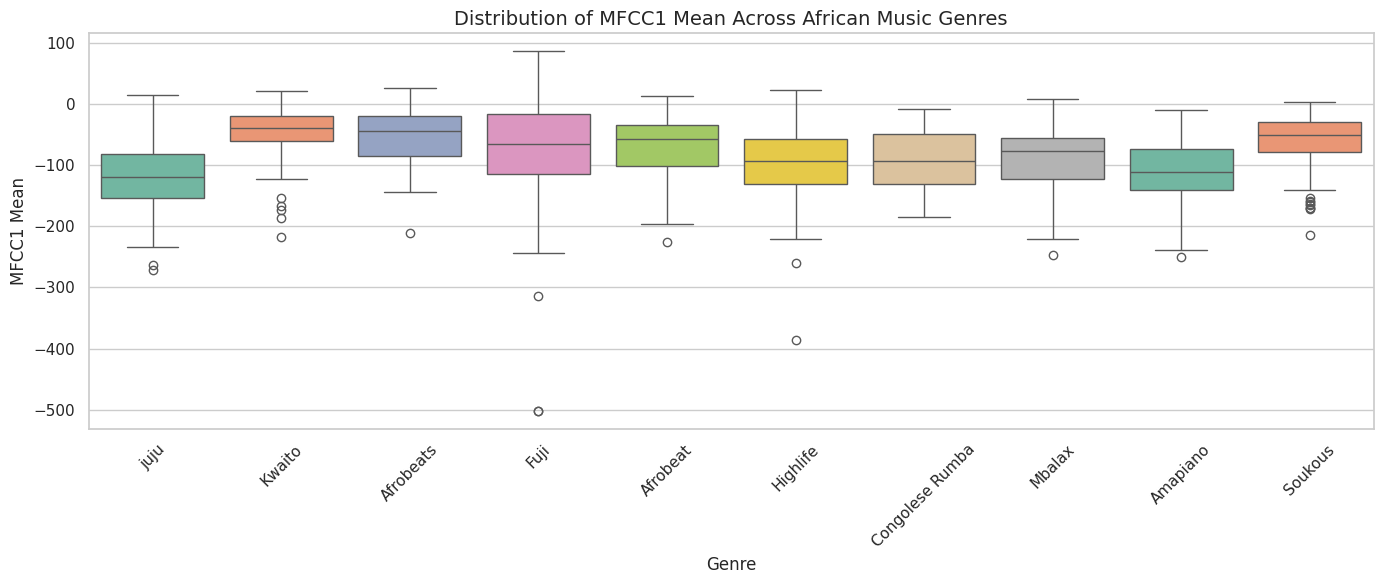

/tmp/ipykernel_585/3548766504.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='spectral_centroid_mean', data=df, palette='Set2')


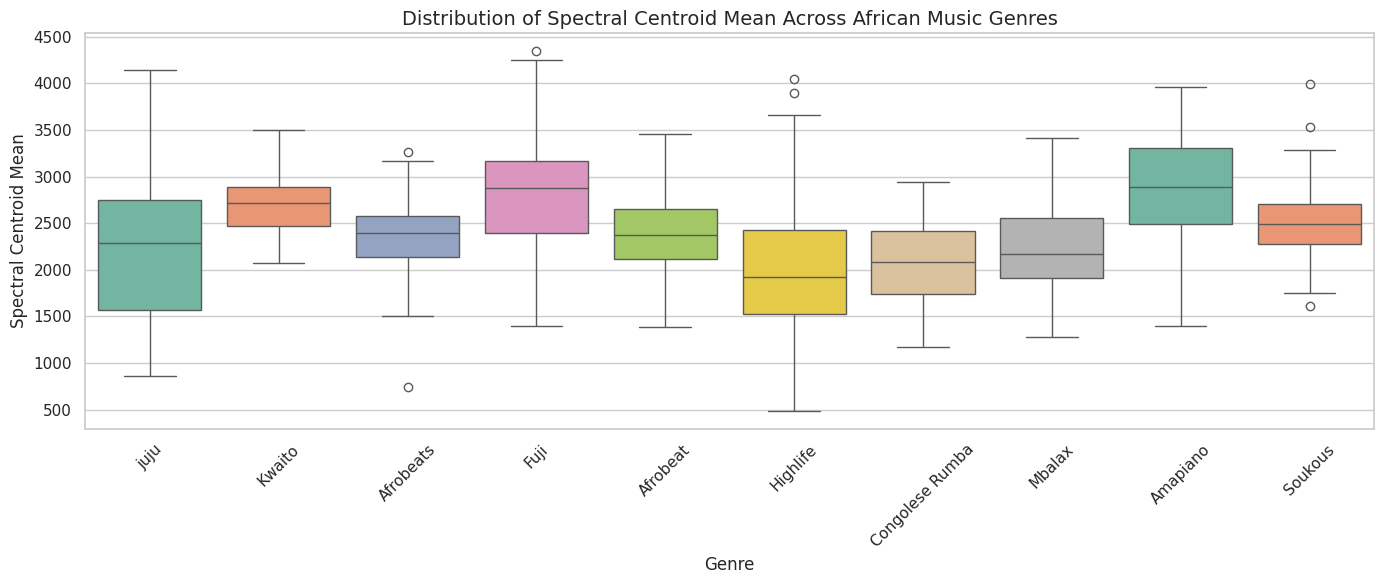

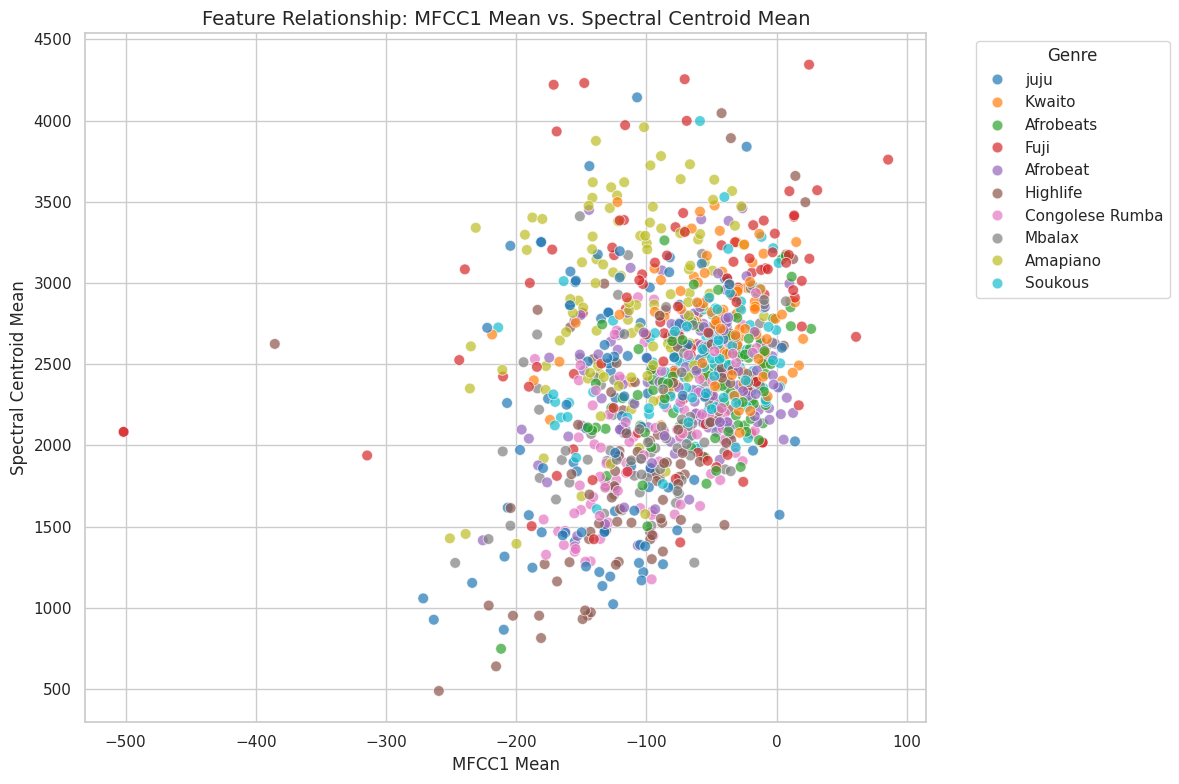

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------
# 1. Box Plots: Distribution of Features by Genre
# ---------------------------------------------------

# Box plot for MFCC1 Mean
plt.figure(figsize=(14, 6))
sns.boxplot(x='genre', y='mfcc1_mean', data=df, palette='Set2')
plt.title('Distribution of MFCC1 Mean Across African Music Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('MFCC1 Mean', fontsize=12)
plt.xticks(rotation=45) # Rotates genre labels so they don't overlap
plt.tight_layout()
plt.show()

# Box plot for Spectral Centroid Mean
plt.figure(figsize=(14, 6))
sns.boxplot(x='genre', y='spectral_centroid_mean', data=df, palette='Set2')
plt.title('Distribution of Spectral Centroid Mean Across African Music Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Spectral Centroid Mean', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 2. Scatter Plot: Feature Relationships
# ---------------------------------------------------

# Scatter plot comparing MFCC1 Mean and Spectral Centroid Mean
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='mfcc1_mean',
    y='spectral_centroid_mean',
    hue='genre',
    data=df,
    alpha=0.7,
    palette='tab10',
    s=60 # Marker size
)

plt.title('Feature Relationship: MFCC1 Mean vs. Spectral Centroid Mean', fontsize=14)
plt.xlabel('MFCC1 Mean', fontsize=12)
plt.ylabel('Spectral Centroid Mean', fontsize=12)

# Move the legend outside the plot for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Genre')
plt.tight_layout()
plt.show()

In [ ]:
# y = labels (keep this)
y_train = X_train["genre"]
y_test  = X_test["genre"]

# X = numeric features only (drop text columns)
X_train_num = X_train.drop(columns=["file_name", "file_path", "genre"], errors="ignore")
X_test_num  = X_test.drop(columns=["file_name", "file_path", "genre"], errors="ignore")

# mean/std on features
Mean_train  = X_train_num.mean()
Mean_test   = X_test_num.mean()
stdev_train = X_train_num.std()
stdev_test  = X_test_num.std()

print("Mean:\n{}\n\nStandard Deviation:\n{}".format(Mean_train, stdev_train))


Mean:
zcr_mean         0.097348
zcr_var          0.003401
rms_mean         0.206547
rms_var          0.005243
tempo          120.638045
                  ...    
mfcc18_mean      0.402557
mfcc18_var      55.967163
mfcc19_mean     -3.274294
mfcc19_var      58.933838
mfcc20_mean      0.105226
Length: 90, dtype: float64

Standard Deviation:
zcr_mean        0.032887
zcr_var         0.003080
rms_mean        0.078378
rms_var         0.004221
tempo          22.209132
                 ...    
mfcc18_mean     3.391862
mfcc18_var     18.704300
mfcc19_mean     3.336736
mfcc19_var     24.070453
mfcc20_mean     3.452564
Length: 90, dtype: float64


In [ ]:
X_train_scaled = (X_train_num - Mean_train) / stdev_train
X_test_scaled  = (X_test_num  - Mean_train) / stdev_train

X_train_scaled = X_train_scaled.fillna(0)
X_test_scaled  = X_test_scaled.fillna(0)

print(X_train_scaled)


      zcr_mean   zcr_var  rms_mean   rms_var     tempo  \
72    1.233130  0.100500 -1.985647 -1.136220  1.412078   
898   0.300960  0.467268 -0.784288  0.776423 -0.373310   
44   -0.058833 -0.384946  0.056348 -0.149283 -0.373310   
309   0.043695 -0.031998  0.379374  1.358517 -0.143374   
784  -0.317097 -0.307839  1.306337 -0.581077 -0.143374   
...        ...       ...       ...       ...       ...   
330   0.428333 -0.627255 -1.397420 -0.979383  3.517922   
466  -1.652890 -0.720729 -0.401248  3.941443 -0.373310   
121   0.267659 -0.726227 -1.240782 -0.925179  0.108461   
1044  3.558840  1.321136  0.918234 -0.218701  0.691658   
860  -0.565076 -0.730403  0.341552  0.316823  5.145164   

      spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
72                  1.432748              -0.225687                 1.080491   
898                 0.997705               2.824294                 0.968091   
44                  1.217749              -0.071996            

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Use your scaled features (DataFrames) -> convert to numpy for sklearn
Xtr = X_train_scaled.to_numpy()
Xte = X_test_scaled.to_numpy()
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

models = {
    "SVM (RBF)": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=5000, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced", n_jobs=-1),
    "Perceptron (SGD)": make_pipeline(StandardScaler(), SGDClassifier(loss="perceptron", max_iter=2000, tol=1e-3, random_state=42)),
}

results = []

for name, model in models.items():
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    results.append((name, acc))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
print(results_df.to_string(index=False))

# Optional: detailed report for the best model
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_pred = best_model.predict(Xte)

print("\nBest model:", best_name)
print(classification_report(yte, best_pred))


              Model  Accuracy
          SVM (RBF)  0.723005
Logistic Regression  0.680751
      Random Forest  0.671362
  Gradient Boosting  0.661972
   Perceptron (SGD)  0.638498
        Naive Bayes  0.558685
      Decision Tree  0.370892

Best model: SVM (RBF)
                 precision    recall  f1-score   support

       Afrobeat       0.56      0.76      0.64        25
      Afrobeats       0.77      0.68      0.72        25
       Amapiano       0.79      0.86      0.83        22
Congolese Rumba       0.74      0.81      0.77        21
           Fuji       0.89      0.73      0.80        22
       Highlife       0.64      0.58      0.61        24
         Kwaito       0.75      0.80      0.77        15
         Mbalax       0.74      0.70      0.72        20
        Soukous       0.79      0.75      0.77        20
           juju       0.69      0.58      0.63        19

       accuracy                           0.72       213
      macro avg       0.74      0.73      0.73     

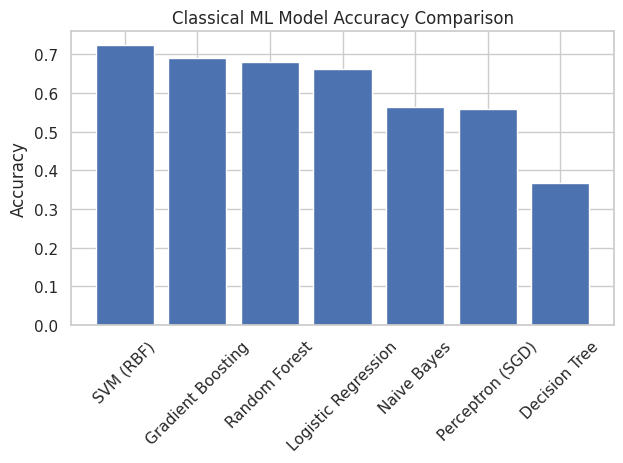

In [ ]:

models = [
    "SVM (RBF)", "Gradient Boosting", "Random Forest",
    "Logistic Regression", "Naive Bayes",
    "Perceptron (SGD)", "Decision Tree"
]

accuracies = [0.723005, 0.690141, 0.680751,
              0.661972, 0.563380,
              0.558685, 0.366197]

plt.figure()
plt.bar(models, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Classical ML Model Accuracy Comparison")
plt.tight_layout()
plt.show()

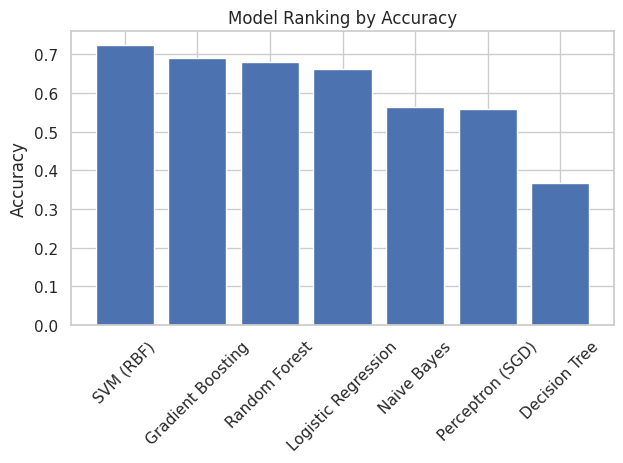

In [ ]:
import matplotlib.pyplot as plt

model_acc = {
    "SVM (RBF)": 0.723005,
    "Gradient Boosting": 0.690141,
    "Random Forest": 0.680751,
    "Logistic Regression": 0.661972,
    "Naive Bayes": 0.563380,
    "Perceptron (SGD)": 0.558685,
    "Decision Tree": 0.366197
}

sorted_models = sorted(model_acc.items(), key=lambda x: x[1], reverse=True)
models, accuracies = zip(*sorted_models)

plt.figure()
plt.bar(models, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Ranking by Accuracy")
plt.tight_layout()
plt.show()

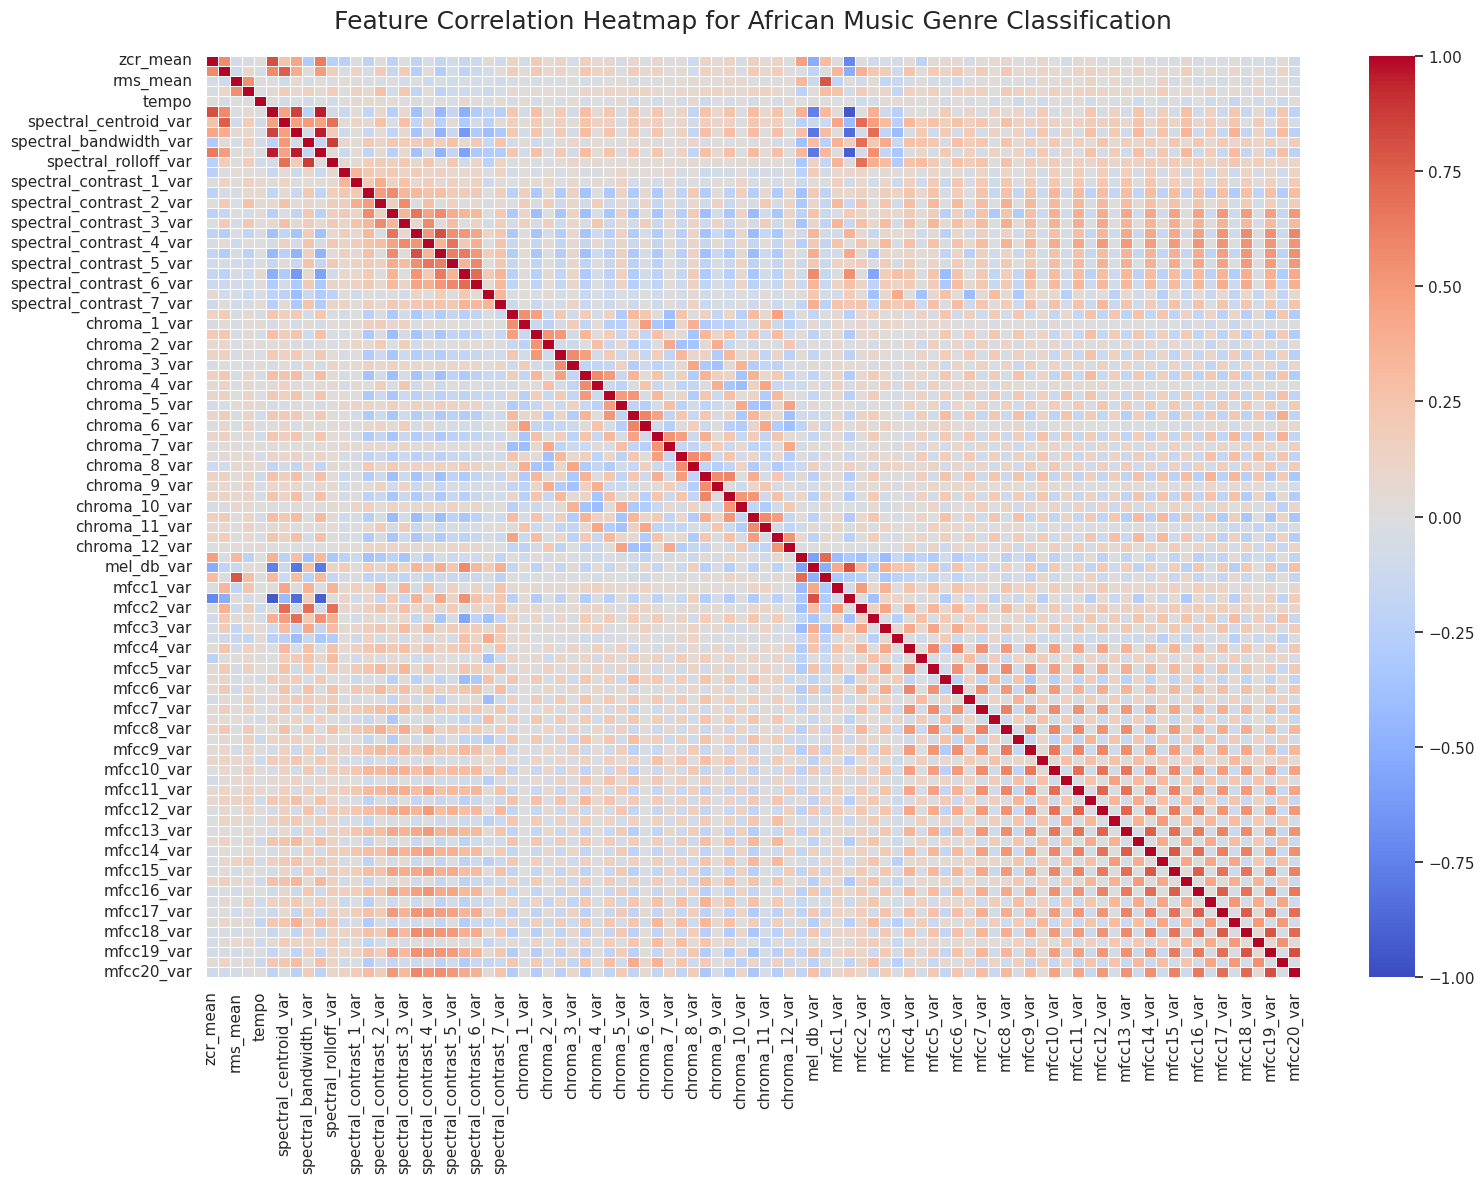

In [ ]:
# Heat Map Correlation for AFMGC features

num_df = df.select_dtypes(include=['float64', 'int64'])
if 'length' in num_df.columns:
    num_df = num_df.drop(columns=['length'])

# 2. Calculate the correlation matrix
corr_matrix = num_df.corr()

# 3. Plot the heatmap using seaborn
plt.figure(figsize=(16, 12))

# We use the 'coolwarm' colormap: Red = Positive Correlation, Blue = Negative Correlation
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,          # Set to True if you want to see the actual numbers (can get messy with many features)
    linewidths=0.5,
    vmin=-1,              # Correlation ranges from -1 to 1
    vmax=1,
    center=0
)

plt.title('Feature Correlation Heatmap for African Music Genre Classification', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

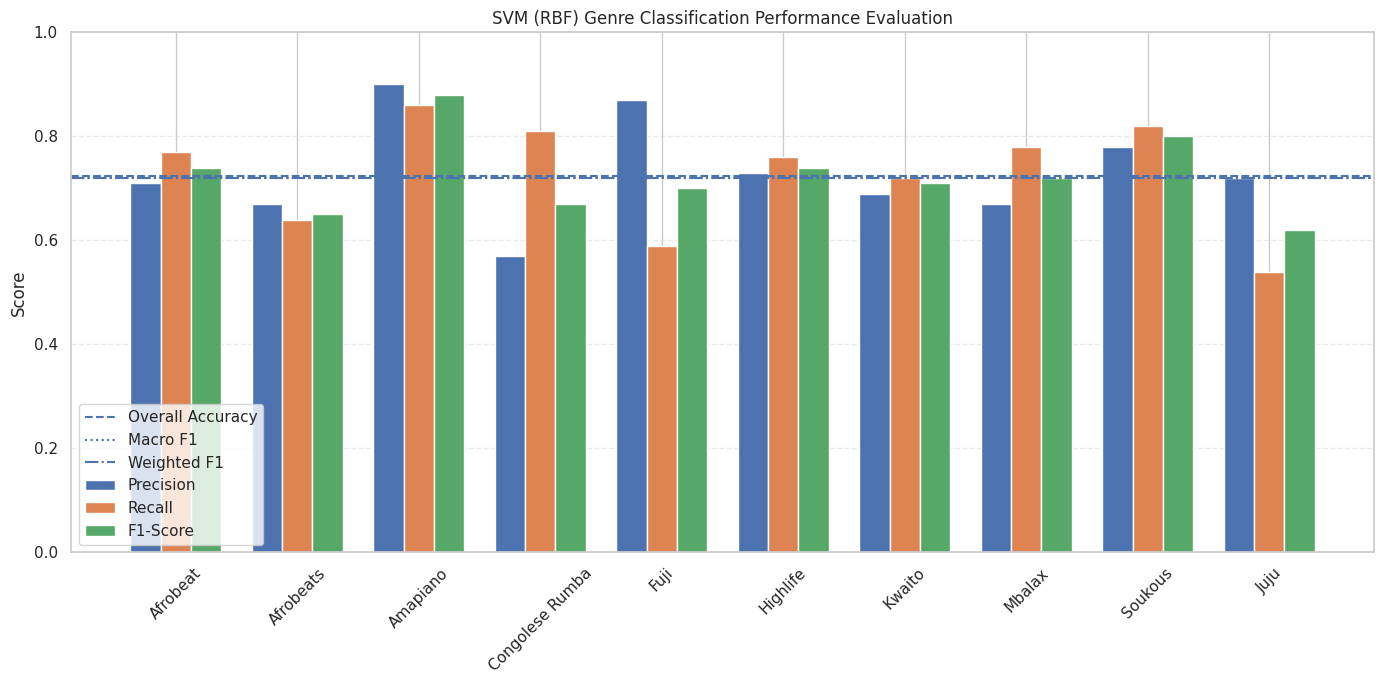

In [ ]:
# Data
genres = [
    "Afrobeat", "Afrobeats", "Amapiano", "Congolese Rumba",
    "Fuji", "Highlife", "Kwaito", "Mbalax", "Soukous", "Juju"
]

precision = [0.71,0.67,0.90,0.57,0.87,0.73,0.69,0.67,0.78,0.72]
recall    = [0.77,0.64,0.86,0.81,0.59,0.76,0.72,0.78,0.82,0.54]
f1        = [0.74,0.65,0.88,0.67,0.70,0.74,0.71,0.72,0.80,0.62]

overall_accuracy = 0.723
macro_f1 = 0.72
weighted_f1 = 0.72

x = np.arange(len(genres))
width = 0.25

plt.figure(figsize=(14, 7))

# Bars
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-Score")

# Reference lines
plt.axhline(overall_accuracy, linestyle="--", linewidth=1.5, label="Overall Accuracy")
plt.axhline(macro_f1, linestyle=":", linewidth=1.5, label="Macro F1")
plt.axhline(weighted_f1, linestyle="-.", linewidth=1.5, label="Weighted F1")

plt.xticks(x, genres, rotation=45)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("SVM (RBF) Genre Classification Performance Evaluation")
plt.legend(loc="lower left")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

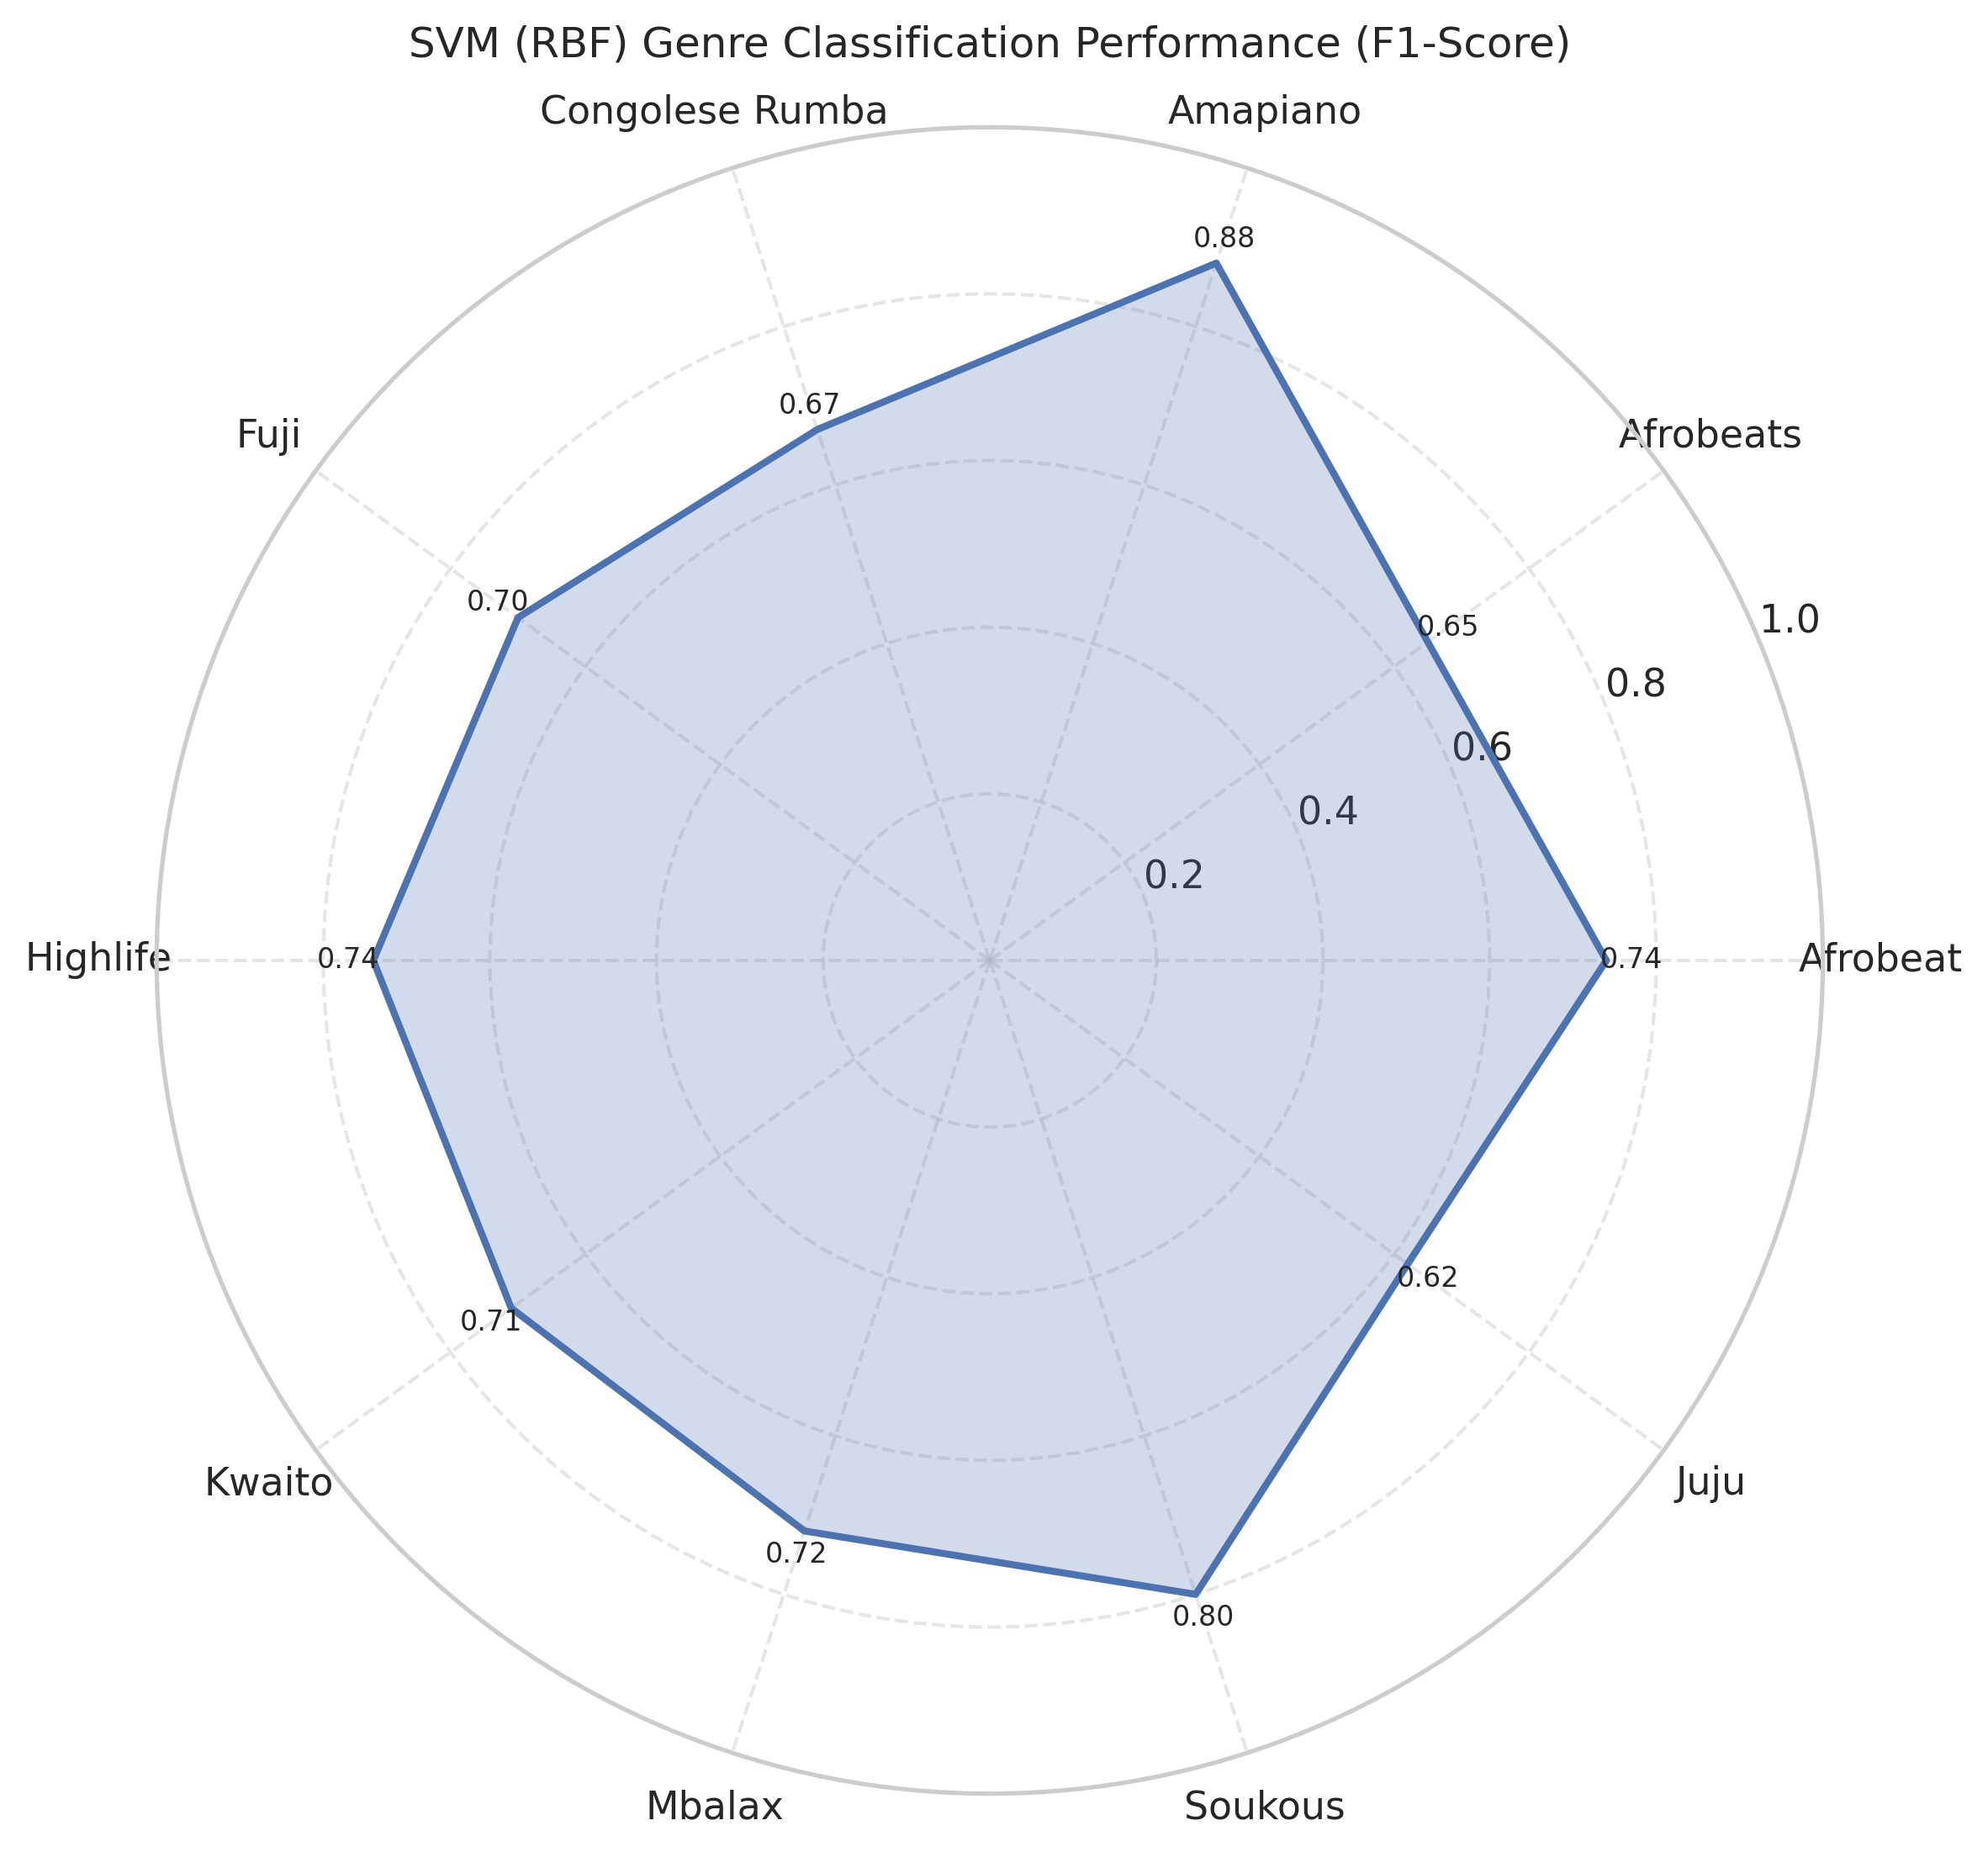

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
genres = [
    "Afrobeat","Afrobeats","Amapiano","Congolese Rumba",
    "Fuji","Highlife","Kwaito","Mbalax","Soukous","Juju"
]

f1_scores = [0.74,0.65,0.88,0.67,0.70,0.74,0.71,0.72,0.80,0.62]

# Close the radar loop
angles = np.linspace(0, 2*np.pi, len(genres), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))
scores = f1_scores + [f1_scores[0]]

# Controlled figure size (inches) + DPI
plt.figure(figsize=(8, 8), dpi=300)

ax = plt.subplot(111, polar=True)

# Plot
ax.plot(angles, scores, linewidth=2)
ax.fill(angles, scores, alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(genres)

# Radial limits
ax.set_ylim(0, 1)

# Grid styling
ax.grid(True, linestyle="--", alpha=0.5)

# Title
plt.title("SVM (RBF) Genre Classification Performance (F1-Score)",
          pad=20)

# Annotate values
for angle, score in zip(angles[:-1], f1_scores):
    ax.text(angle, score + 0.03, f"{score:.2f}",
            ha='center', va='center', fontsize=8)

plt.tight_layout()

# Save high-resolution thesis version
plt.savefig("SVM_Radar_F1_Thesis.png", dpi=600, bbox_inches="tight")

plt.show()

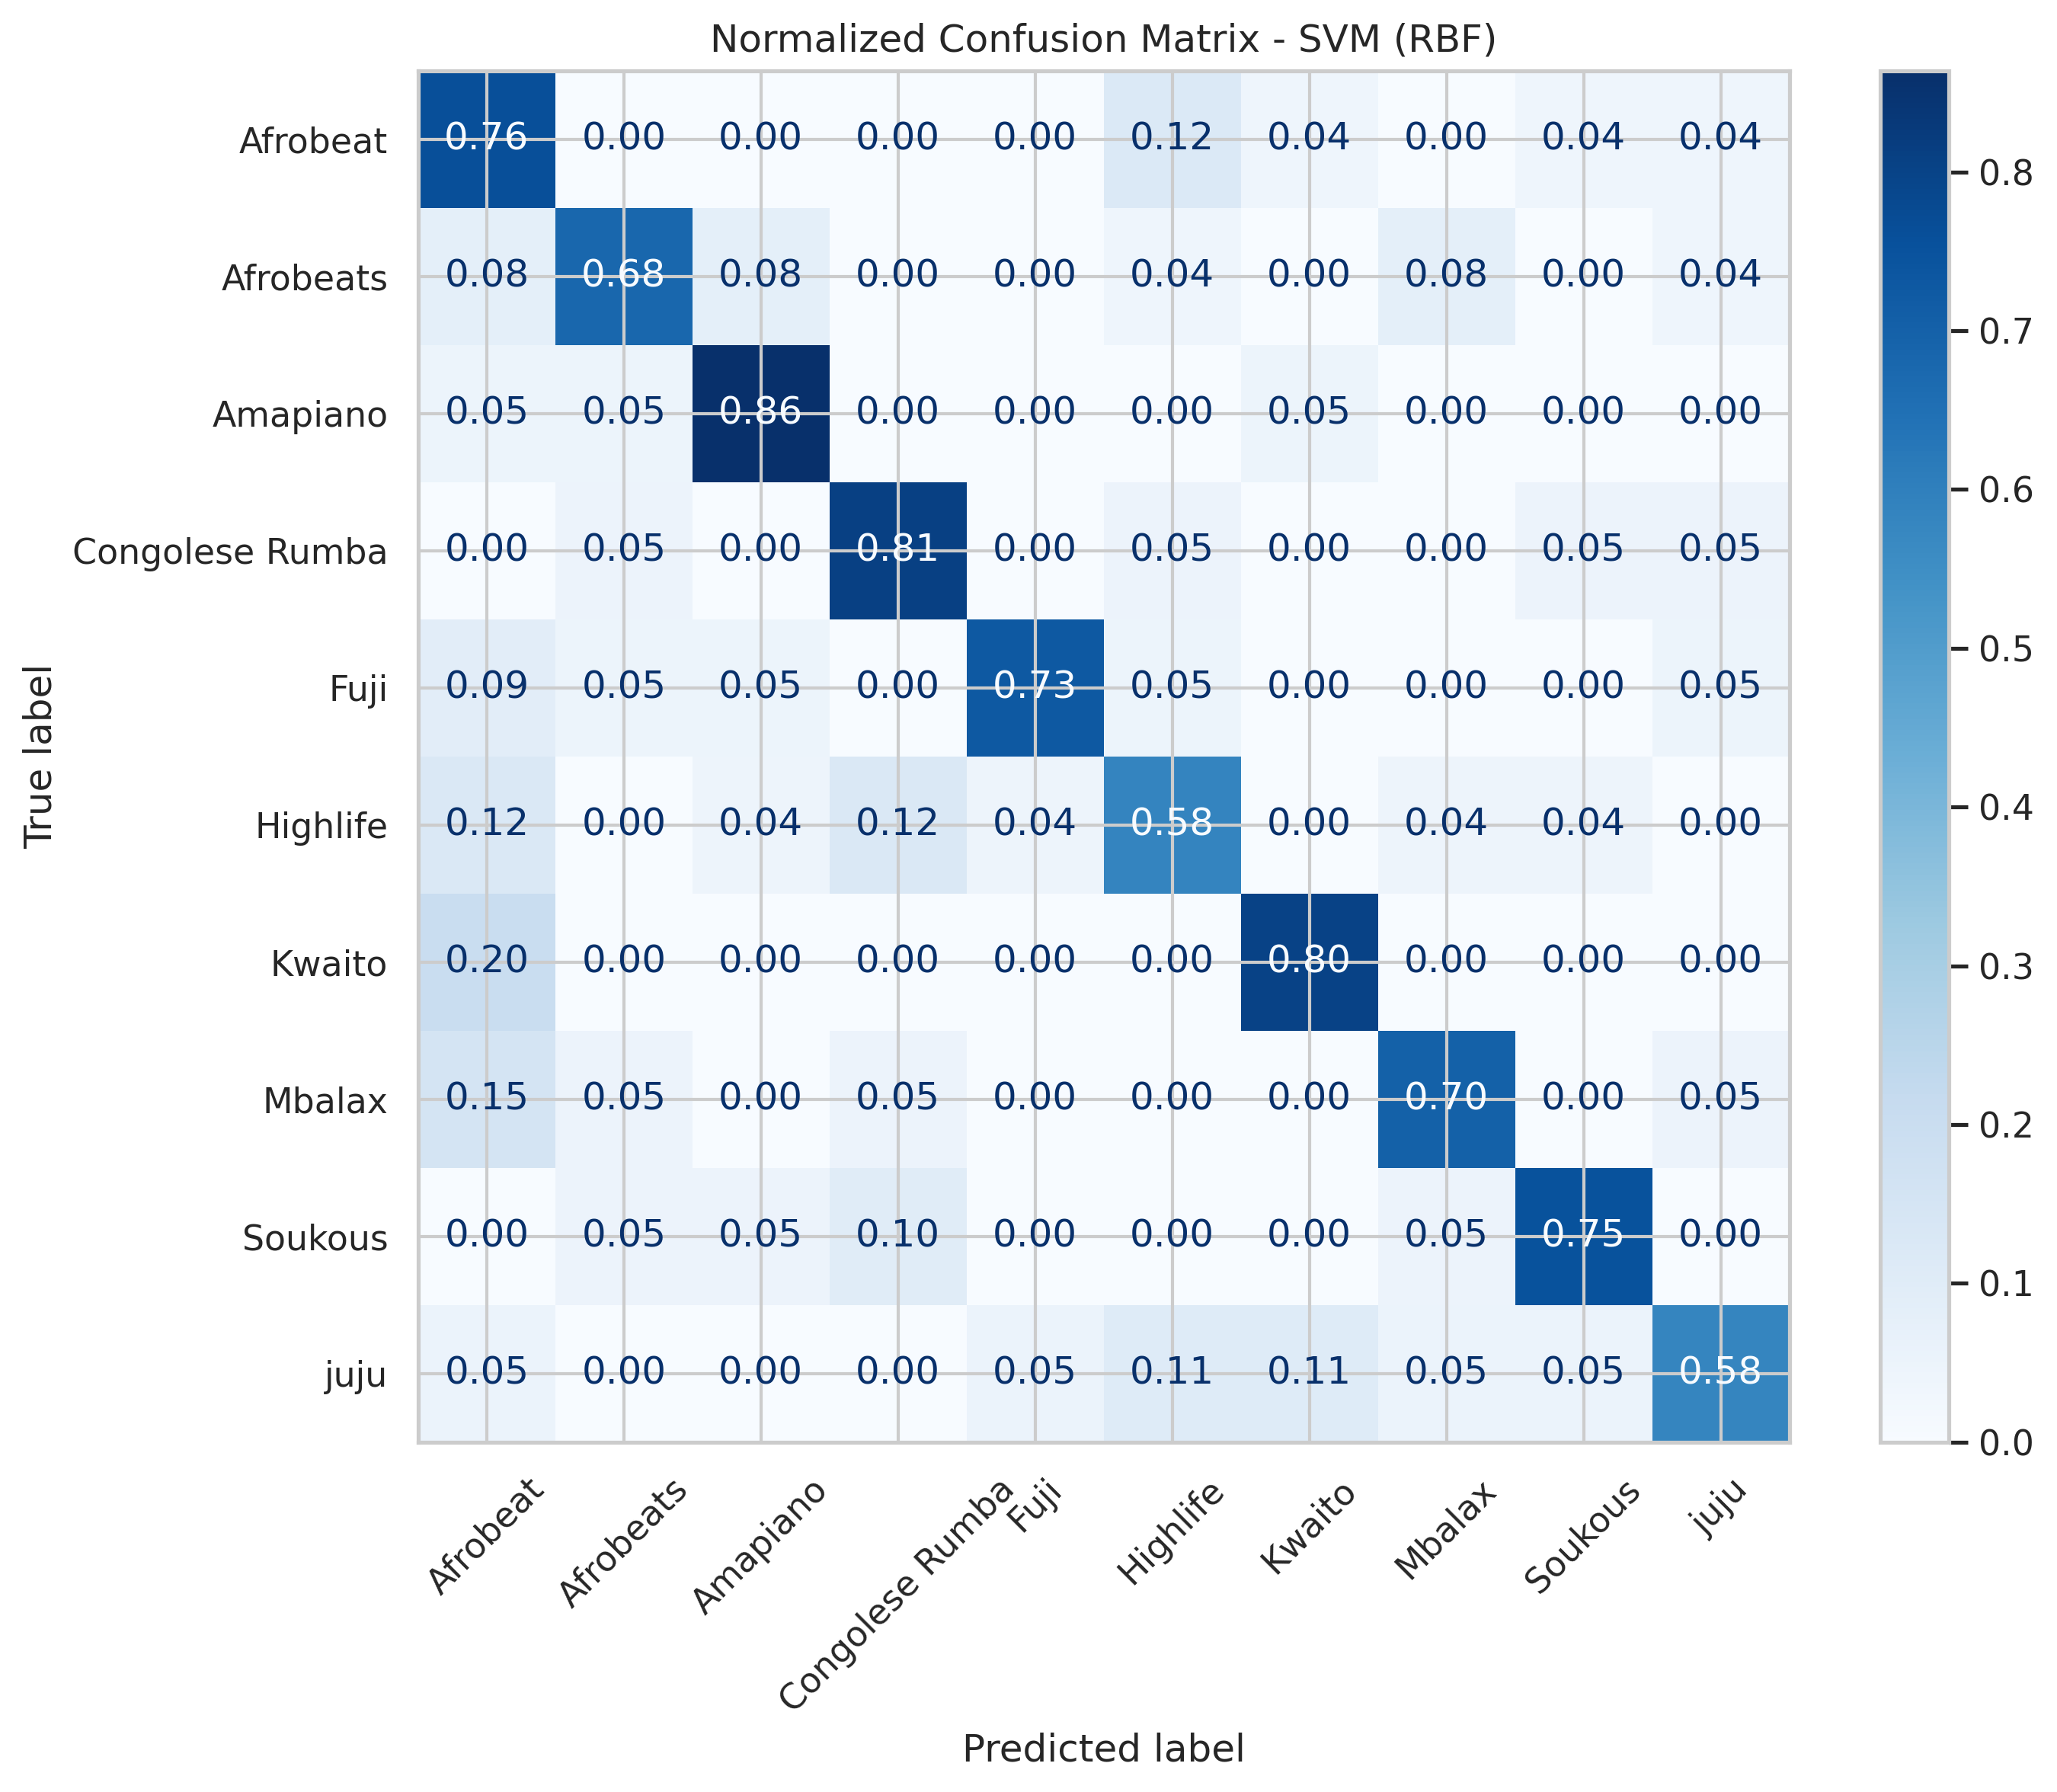

In [ ]:
# Get sorted unique labels
genres = np.unique(yte)

# Compute normalized confusion matrix
cm = confusion_matrix(yte, best_pred, labels=genres, normalize="true")

plt.figure(figsize=(10, 8), dpi=300)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=genres)

disp.plot(cmap="Blues", values_format=".2f", ax=plt.gca())

plt.title(f"Normalized Confusion Matrix - {best_name}")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{best_name}_Confusion_Matrix.png", dpi=600, bbox_inches="tight")
plt.show()

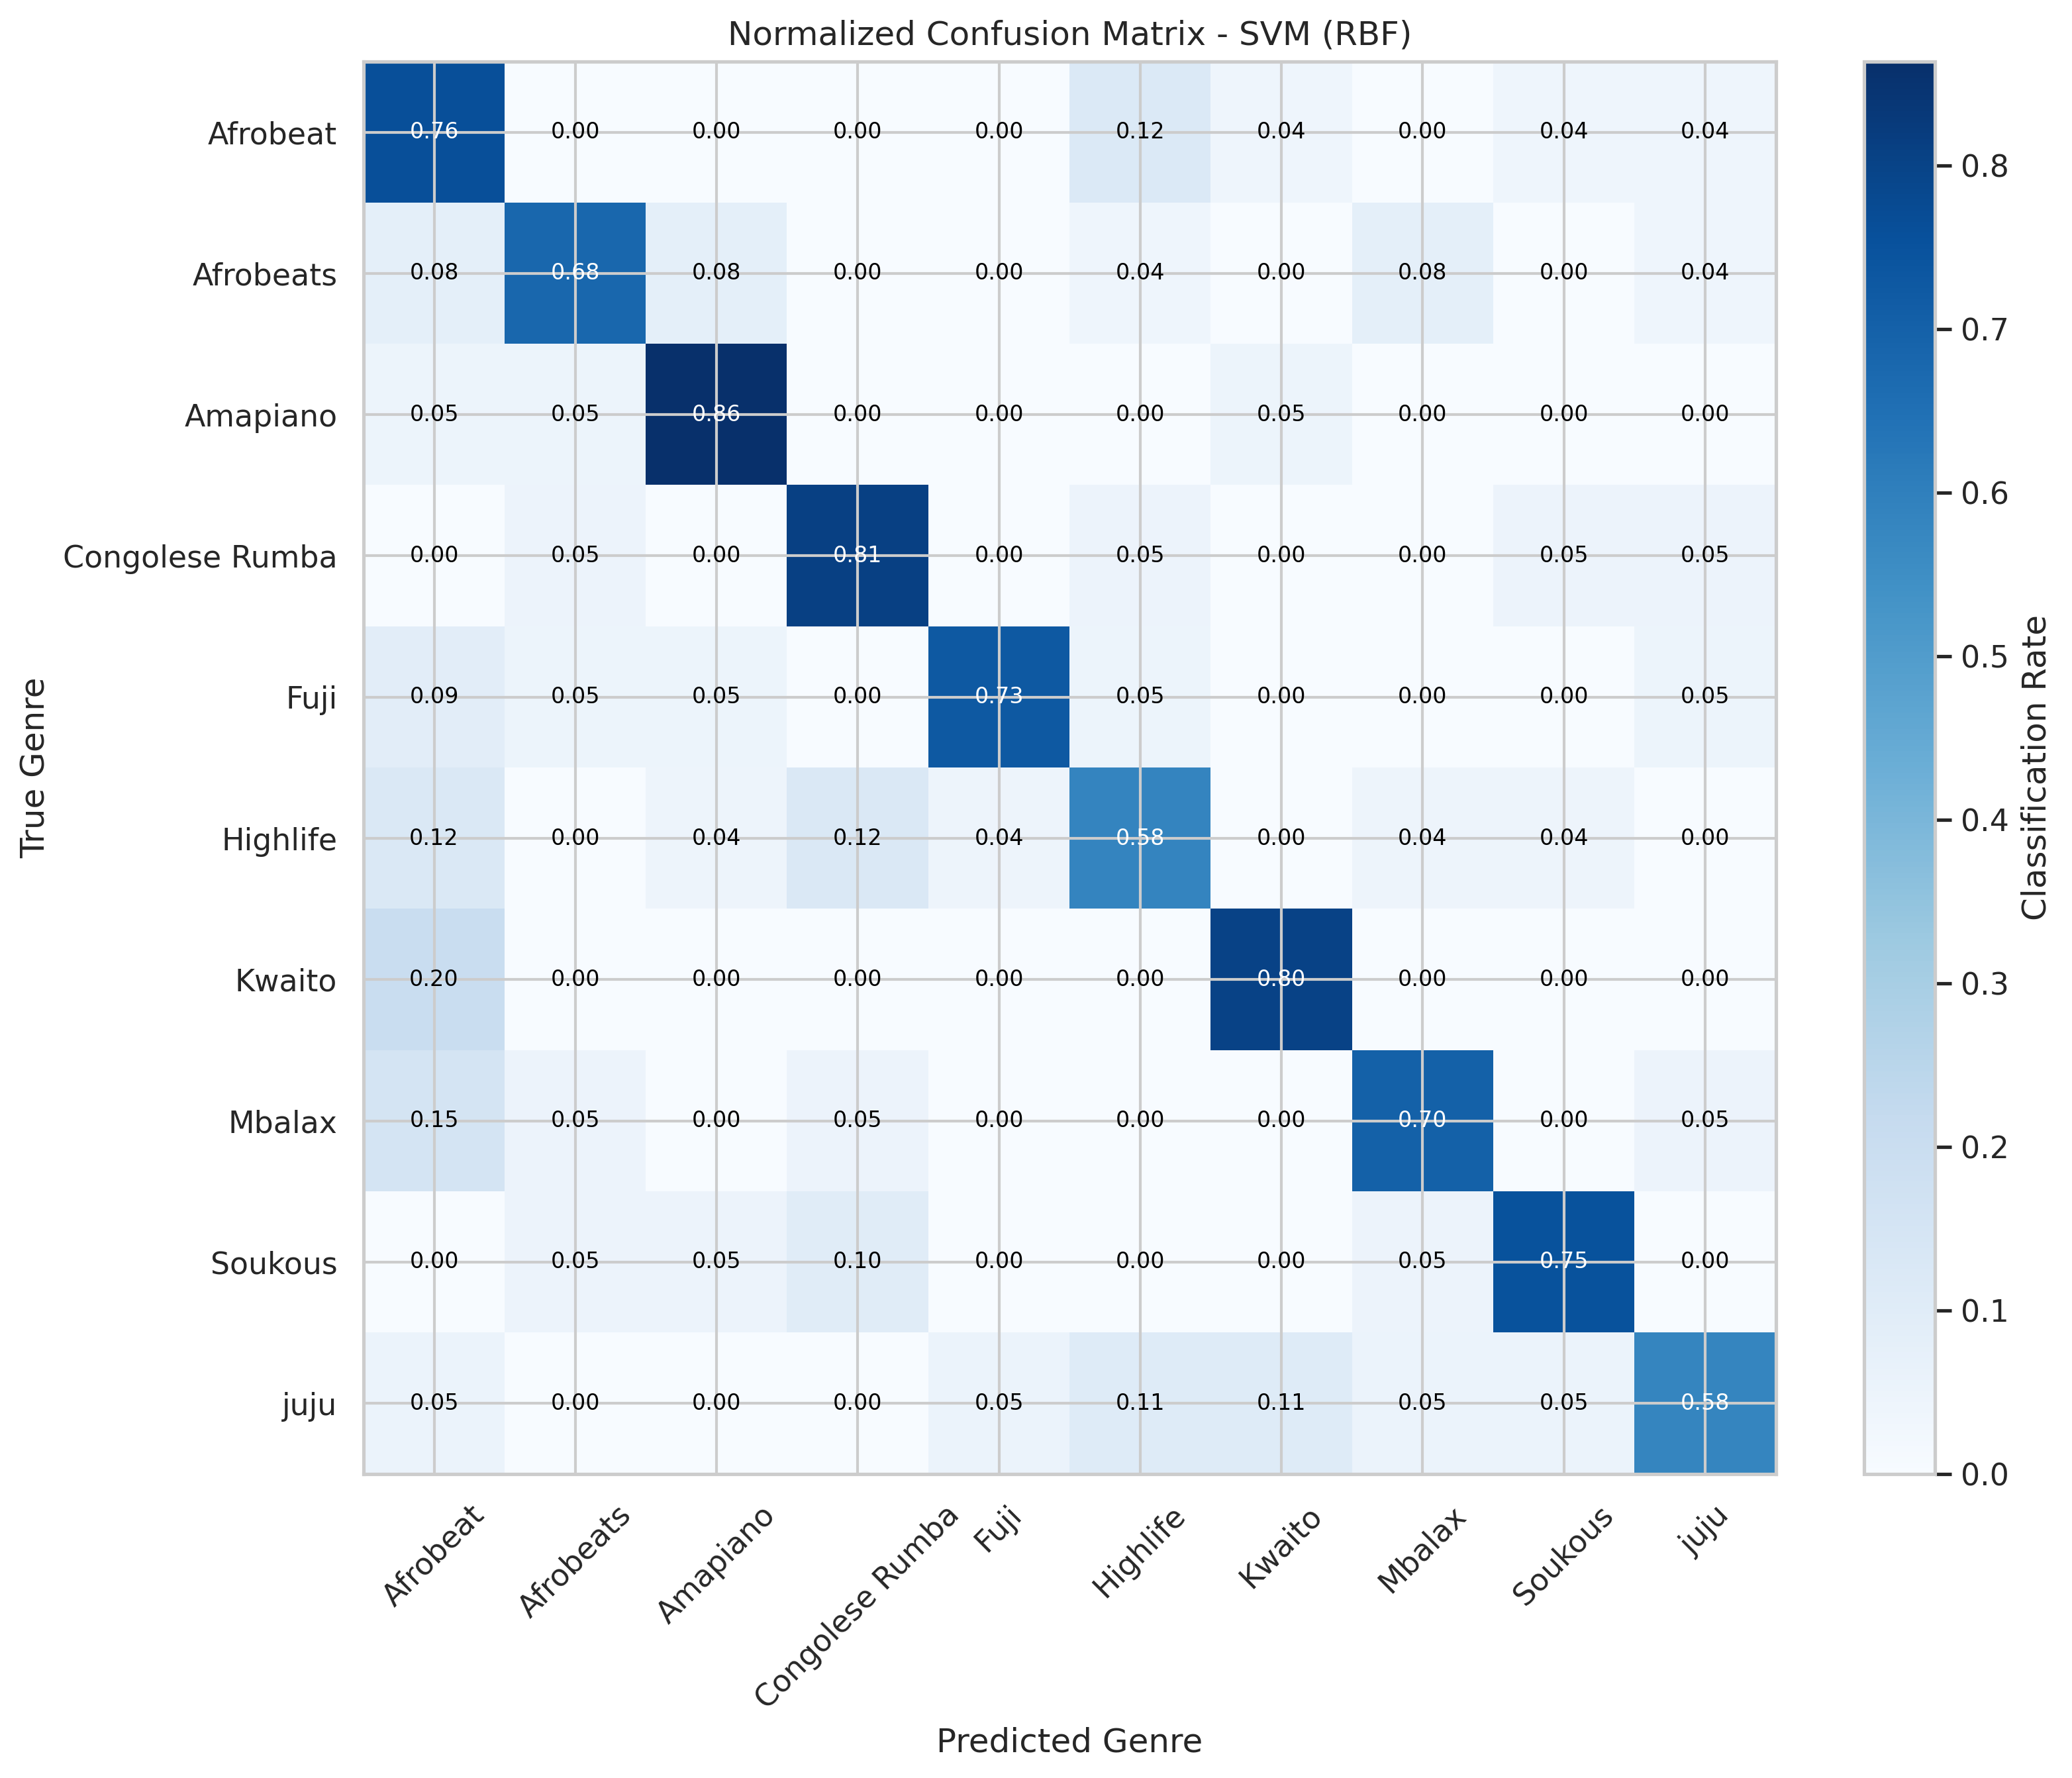


Per-Class Accuracy Ranking:
          Genre  Per-Class Accuracy
       Amapiano            0.863636
Congolese Rumba            0.809524
         Kwaito            0.800000
       Afrobeat            0.760000
        Soukous            0.750000
           Fuji            0.727273
         Mbalax            0.700000
      Afrobeats            0.680000
       Highlife            0.583333
           juju            0.578947


In [ ]:
cm = confusion_matrix(yte, best_pred, labels=genres)
cm_norm = confusion_matrix(yte, best_pred, labels=genres, normalize="true")

# Per-class accuracy (diagonal of normalized matrix)
per_class_acc = np.diag(cm_norm)

plt.figure(figsize=(11, 9), dpi=300)
plt.imshow(cm_norm, interpolation="nearest", cmap="Blues")
plt.colorbar(label="Classification Rate")

plt.xticks(np.arange(len(genres)), genres, rotation=45)
plt.yticks(np.arange(len(genres)), genres)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title(f"Normalized Confusion Matrix - {best_name}")

for i in range(len(genres)):
    for j in range(len(genres)):
        value = cm_norm[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center",
                 va="center",
                 fontsize=8,
                 color="white" if value > 0.5 else "black")

plt.tight_layout()
plt.savefig("Distinction_Confusion_Matrix.png", dpi=600, bbox_inches="tight")
plt.show()

# Print per-class accuracy table
analysis_df = pd.DataFrame({
    "Genre": genres,
    "Per-Class Accuracy": per_class_acc
}).sort_values("Per-Class Accuracy", ascending=False)

print("\nPer-Class Accuracy Ranking:")
print(analysis_df.to_string(index=False))